In [23]:
# IMPORTING LIBRARIES  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# READING DATASET
df=pd.read_csv('online_retail.csv',encoding='unicode_escape')

In [25]:
# CHECKING DATA TYPES
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [26]:
#CHECKING DATA SET
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
df.shape

(541909, 8)

In [28]:
# CHECKING FOR NULL VALUES
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [29]:
#DROPPING NULL VALUES
df.dropna(subset=['CustomerID'],inplace=True)

In [30]:
# CONVERTING CUSTOMERID TO INTEGER
df['CustomerID'] = df['CustomerID'].astype('int')

In [31]:
# CHECKING FOR DUPLICATES
df.duplicated().sum()
# DROPPING DUPLICATES
df.drop_duplicates(inplace=True)

In [32]:
# REMOVING CANCELED ORDERS
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [33]:
# Remove invalid Quantity
df = df[df['Quantity'] > 0]

In [34]:
# Remove invalid UnitPrice
df = df[df['UnitPrice'] > 0]

In [35]:
#checking the shape of the cleaned dataset
print(df.shape)

print("Missing CustomerID:", df['CustomerID'].isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Cancelled Invoices:", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

(392692, 8)
Missing CustomerID: 0
Duplicate rows: 0
Cancelled Invoices: 0
Quantity <= 0: 0
UnitPrice <= 0: 0


In [36]:
# Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Date features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df['MonthNo'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

In [37]:
# Making KPIs
# Total Revenue
total_revenue = df['TotalAmount'].sum()

# Total Orders
total_orders = df['InvoiceNo'].nunique()

# Total Customers
total_customers = df['CustomerID'].nunique()

# Average Order Value
avg_order_value = df.groupby('InvoiceNo')['TotalAmount'].sum().mean()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Average Order Value: £{avg_order_value:,.2f}")

Total Revenue: £8,887,208.89
Total Orders: 18532
Total Customers: 4338
Average Order Value: £479.56


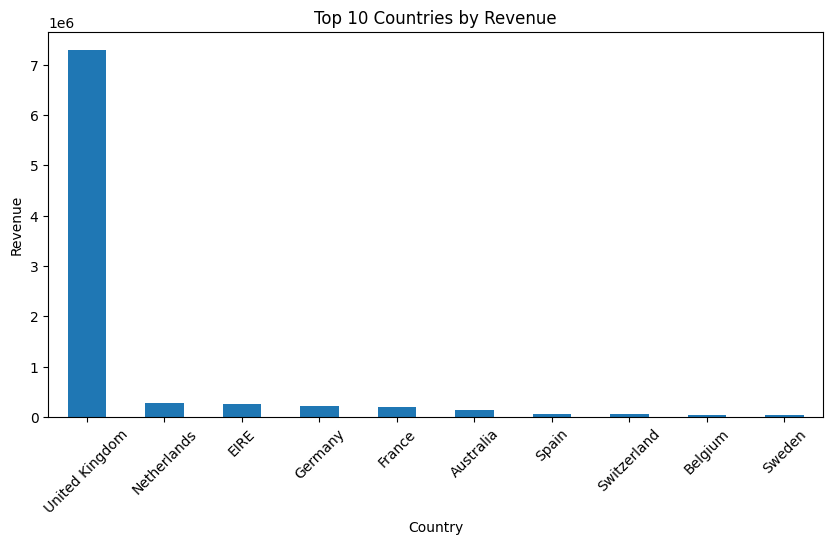

In [38]:


country_sales = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

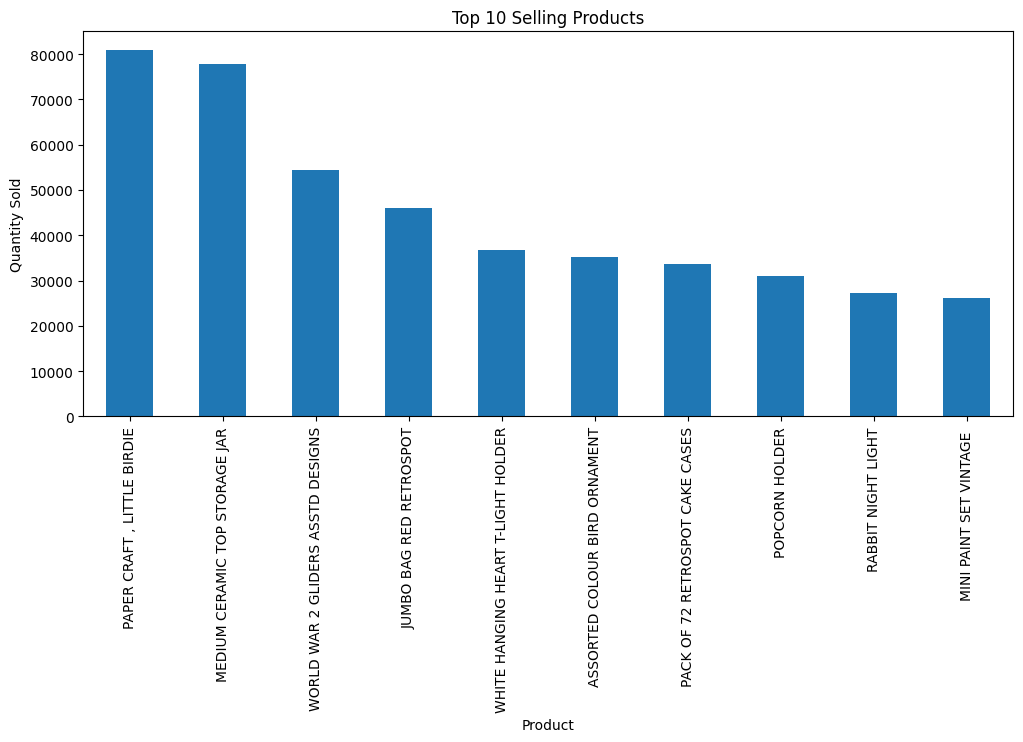

In [39]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()

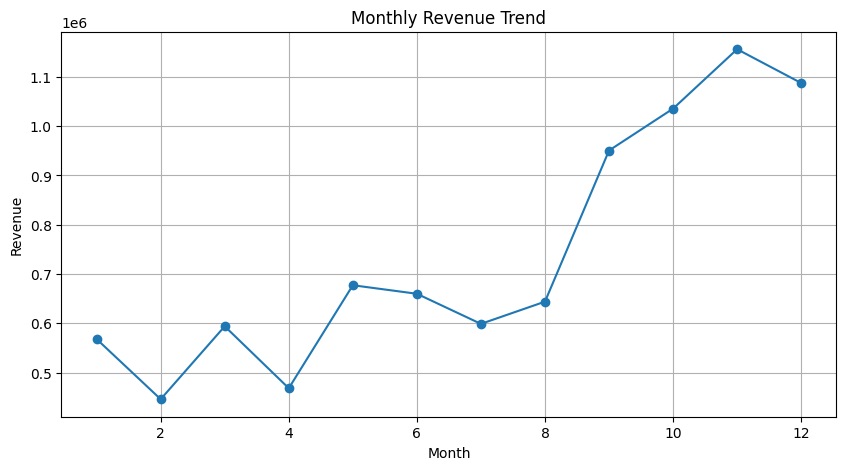

In [40]:
monthly_sales = (
    df.groupby('MonthNo')['TotalAmount']
      .sum()
)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

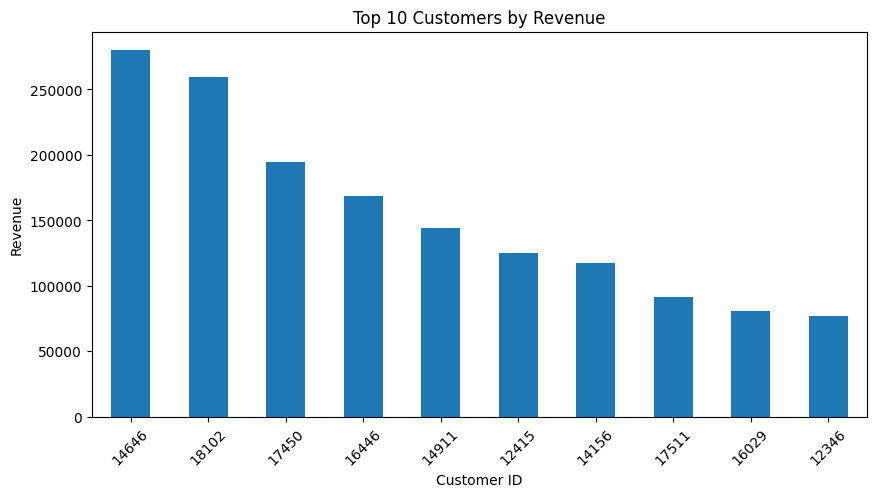

In [41]:
top_customers = (
    df.groupby('CustomerID')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

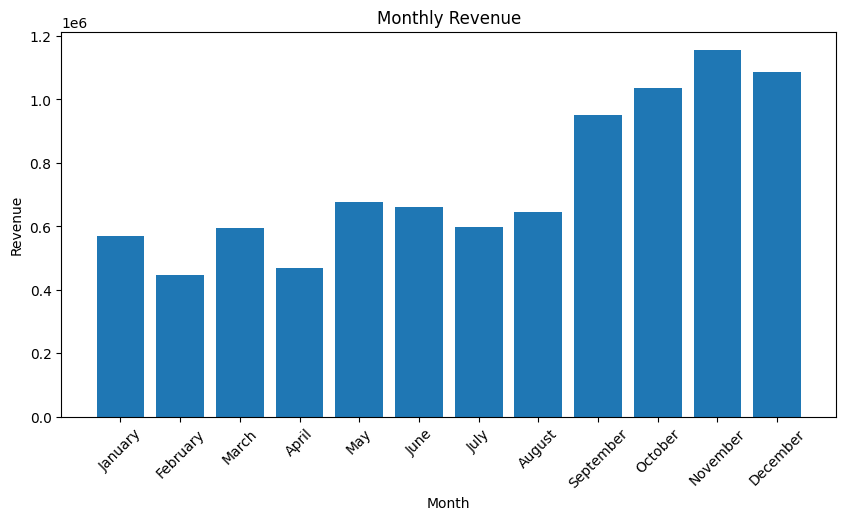

In [42]:
monthly_revenue = (
    df.groupby(['MonthNo','Month'])['TotalAmount']
      .sum()
      .reset_index()
      .sort_values('MonthNo')
)

plt.figure(figsize=(10,5))
plt.bar(monthly_revenue['Month'], monthly_revenue['TotalAmount'])
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

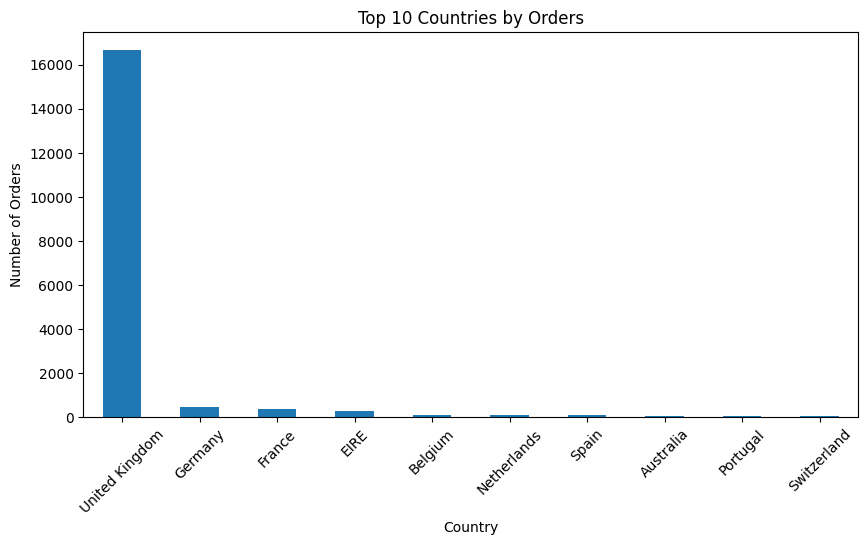

In [43]:
orders_country = (
    df.groupby('Country')['InvoiceNo']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
orders_country.plot(kind='bar')
plt.title("Top 10 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

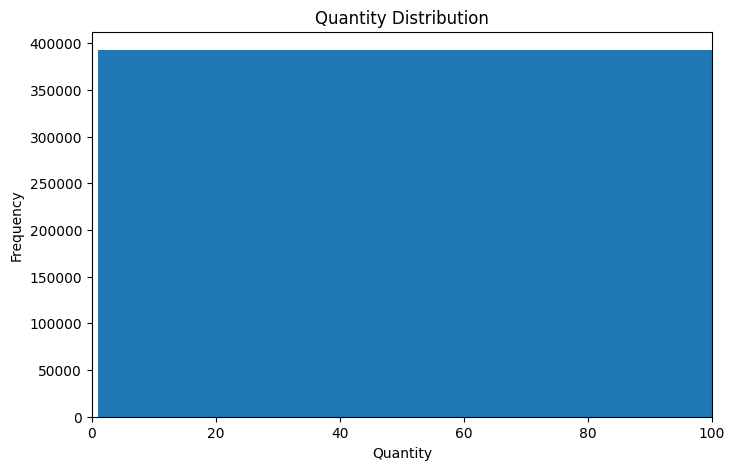

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.xlim(0,100)
plt.show()

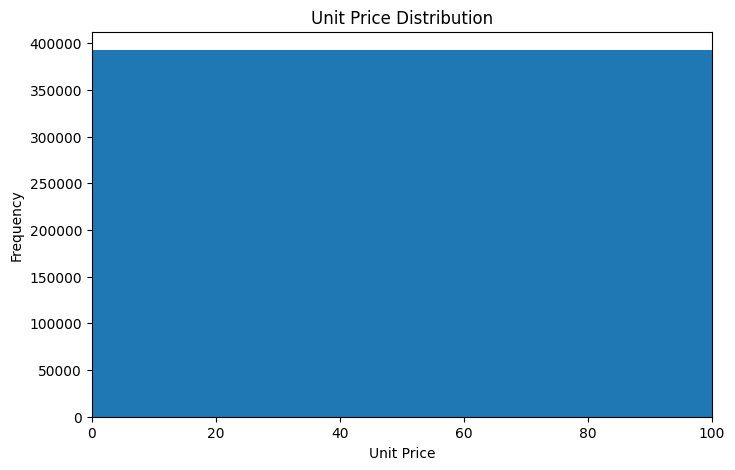

In [45]:
plt.figure(figsize=(8,5))
plt.hist(df['UnitPrice'], bins=50)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.xlim(0,100)
plt.show()

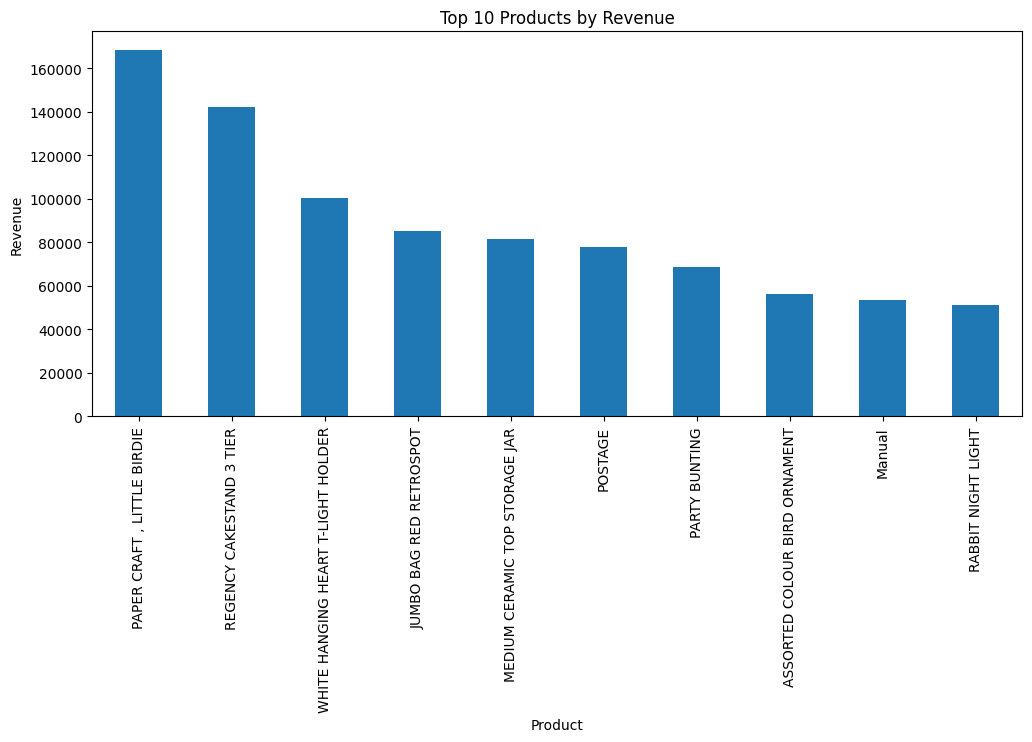

In [46]:
top_products_revenue = (
    df.groupby('Description')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))
top_products_revenue.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

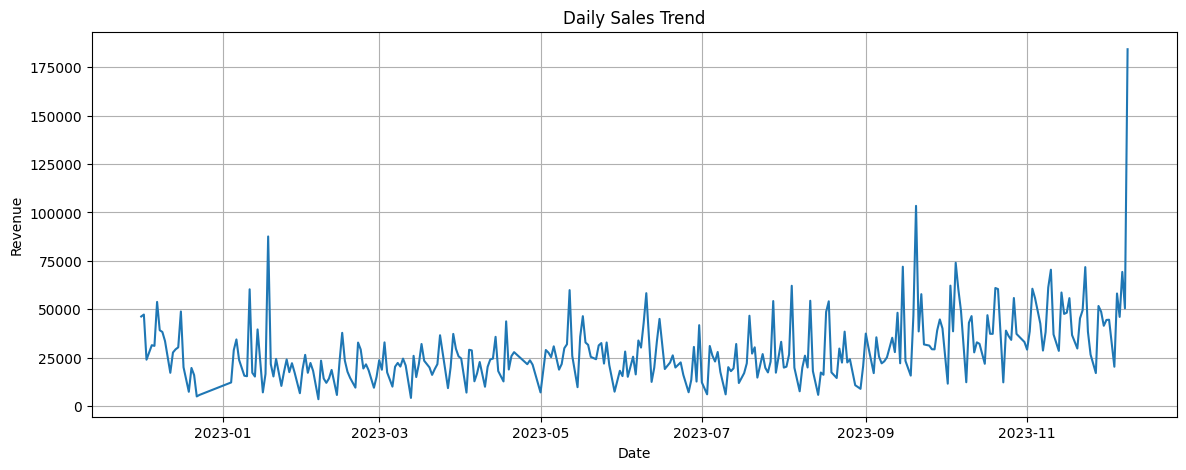

In [47]:
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalAmount']
      .sum()
)

plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

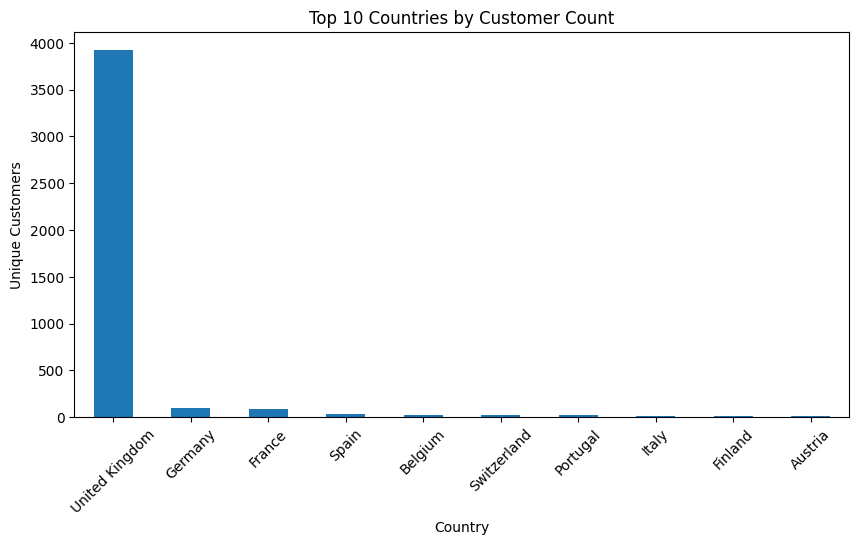

In [48]:
customer_country = (
    df.groupby('Country')['CustomerID']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
customer_country.plot(kind='bar')
plt.title("Top 10 Countries by Customer Count")
plt.xlabel("Country")
plt.ylabel("Unique Customers")
plt.xticks(rotation=45)
plt.show()

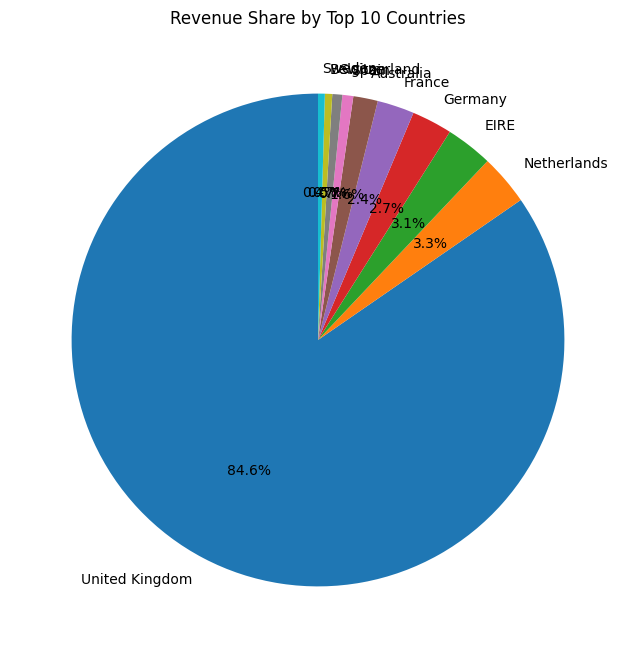

In [49]:
top_country = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(8,8))
plt.pie(top_country,
        labels=top_country.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Revenue Share by Top 10 Countries")
plt.show()

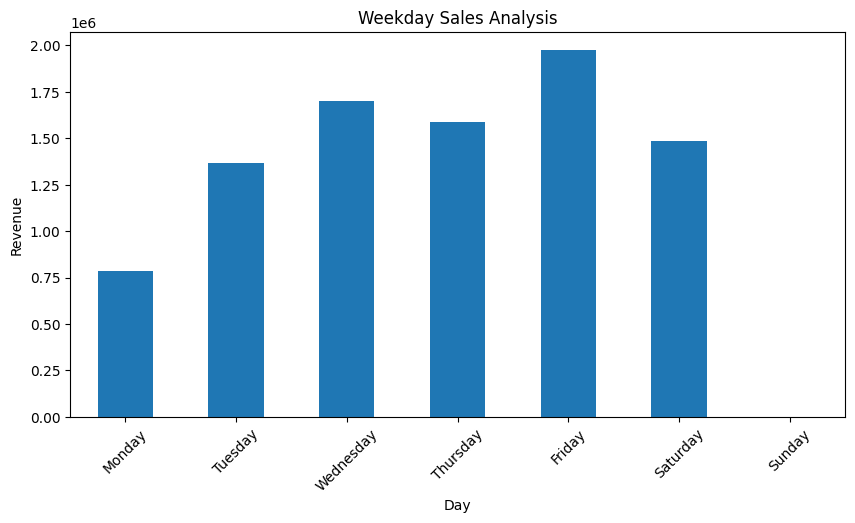

In [50]:
weekday_sales = (
    df.groupby('Weekday')['TotalAmount']
      .sum()
      .reindex([
          'Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
)

plt.figure(figsize=(10,5))
weekday_sales.plot(kind='bar')
plt.title("Weekday Sales Analysis")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

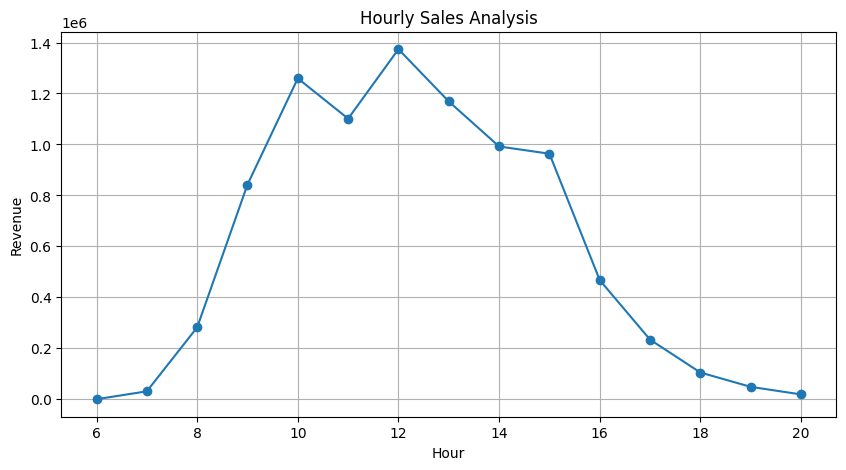

In [51]:
hourly_sales = (
    df.groupby('Hour')['TotalAmount']
      .sum()
)

plt.figure(figsize=(10,5))
hourly_sales.plot(marker='o')
plt.title("Hourly Sales Analysis")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

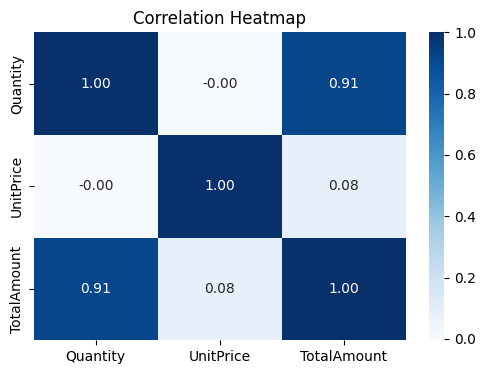

In [52]:


corr = df[['Quantity','UnitPrice','TotalAmount']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr,
            annot=True,
            cmap='Blues',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [53]:
df.to_csv("cleaned_retail.csv", index=False)